In [21]:
from common_helper_functions import *
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
path = "../../../../../../../../../../../s/project/gene_embedding/funcrvp_embeddings/"

omics = pd.read_csv(path + 'omics_d256.tsv', sep='\t')

string = pd.read_csv(path + 'STRING_d128.tsv', sep='\t')

string_exp = pd.read_csv(path + 'STRING_EXP_d128.tsv', sep='\t')

orthrus = pd.read_csv('../preprocessed_data/orthrus_processed.csv')

emogi = pd.read_csv("../preprocessed_data/emogi_preprocessed.tsv", sep='\t')

emogi_predictions = emogi[['gene_id', 'pred']].copy()

In [23]:
orthrus_omics = orthrus.merge(omics, on='gene_id', how='inner')
orthrus_string = orthrus.merge(string, on='gene_id', how='inner')
orthrus_string_exp = orthrus.merge(string_exp, on='gene_id', how='inner')
orthrus_emogi = orthrus.merge(emogi, on='gene_id', how='inner')

# Normalize combined datasets with z-scores


In [24]:
orthrus_omics_normalized = orthrus_omics.copy()
numeric_cols = orthrus_omics.select_dtypes(include=[np.number]).columns
orthrus_omics_normalized[numeric_cols] = (orthrus_omics[numeric_cols] - orthrus_omics[numeric_cols].mean()) / orthrus_omics[numeric_cols].std()

orthrus_string_normalized = orthrus_string.copy()
numeric_cols = orthrus_string.select_dtypes(include=[np.number]).columns
orthrus_string_normalized[numeric_cols] = (orthrus_string[numeric_cols] - orthrus_string[numeric_cols].mean()) / orthrus_string[numeric_cols].std()

orthrus_string_exp_normalized = orthrus_string_exp.copy()
numeric_cols = orthrus_string_exp.select_dtypes(include=[np.number]).columns
orthrus_string_exp_normalized[numeric_cols] = (orthrus_string_exp[numeric_cols] - orthrus_string_exp[numeric_cols].mean()) / orthrus_string_exp[numeric_cols].std()

orthrus_emogi_normalized = orthrus_emogi.copy()
numeric_cols = orthrus_emogi.select_dtypes(include=[np.number]).columns
orthrus_emogi_normalized[numeric_cols] = (orthrus_emogi[numeric_cols] - orthrus_emogi[numeric_cols].mean()) / orthrus_emogi[numeric_cols].std()

In [25]:
def autoencoder_reduce_complex(
        df,
        n_components=128,
        epochs=120,
        batch_size=256,
        latent_activation=None,
        cache_dir="ae_cache",
        dataset_name=None,
        verbose=1,
    ):
        """
        Train a complex fully-connected autoencoder and return latent embeddings as a DataFrame.
        Caches latent CSV and best model under cache_dir.
        """
        os.makedirs(cache_dir, exist_ok=True)
        if dataset_name is None:
            dataset_name = "ae"
        model_path = os.path.join(cache_dir, f"{dataset_name}_best.keras")
        emb_path = os.path.join(cache_dir, f"{dataset_name}_latent.csv")

        # If cached embeddings exist, load and return
        if os.path.exists(emb_path):
            return pd.read_csv(emb_path)

        numeric_cols = df.select_dtypes(include=[np.number]).columns
        X = df[numeric_cols].astype(np.float32).values
        scaler = StandardScaler().fit(X)
        Xs = scaler.transform(X).astype(np.float32)
        input_dim = Xs.shape[1]
        latent_dim = int(n_components)

        # Build deeper encoder with residual blocks
        inputs = layers.Input(shape=(input_dim,))
        x = layers.Dense(1024, activation=None)(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Dropout(0.2)(x)

        # Residual block factory
        def res_block(x_in, units, dropout_rate=0.2):
            shortcut = layers.Dense(units, activation=None)(x_in)
            y = layers.Dense(units, activation=None)(x_in)
            y = layers.BatchNormalization()(y)
            y = layers.Activation("relu")(y)
            y = layers.Dropout(dropout_rate)(y)
            y = layers.Dense(units, activation=None)(y)
            y = layers.BatchNormalization()(y)
            out = layers.Add()([shortcut, y])
            out = layers.Activation("relu")(out)
            return out

        x = res_block(x, 768, dropout_rate=0.25)
        x = res_block(x, 512, dropout_rate=0.25)
        x = layers.Dense(384, activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)

        # Bottleneck / latent
        latent = layers.Dense(latent_dim, activation=latent_activation, name="latent")(x)

        # Decoder mirrors encoder
        x = layers.Dense(384, activation="relu")(latent)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(512, activation="relu")(x)
        x = res_block(x, 512, dropout_rate=0.2)
        x = layers.Dense(768, activation="relu")(x)
        x = layers.BatchNormalization()(x)
        outputs = layers.Dense(input_dim, activation=None)(x)

        ae = keras.Model(inputs, outputs, name=f"ae_{dataset_name}")
        encoder = keras.Model(inputs, latent, name=f"enc_{dataset_name}")

        # Optimizer, lr schedule
        lr_schedule = keras.optimizers.schedules.ExponentialDecay(1e-3, decay_steps=1000, decay_rate=0.96)
        opt = keras.optimizers.Adam(learning_rate=lr_schedule)
        ae.compile(optimizer=opt, loss="mse")

        callbacks = [
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
            keras.callbacks.ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True, save_weights_only=False),
        ]

        # Fit
        ae.fit(Xs, Xs, epochs=epochs, batch_size=batch_size, validation_split=0.1, callbacks=callbacks, shuffle=True, verbose=verbose)

        # Try to load best model and reconstruct encoder if possible
        try:
            ae_best = keras.models.load_model(model_path)
            if "latent" in [l.name for l in ae_best.layers]:
                latent_layer = ae_best.get_layer("latent").output
                encoder = keras.Model(ae_best.input, latent_layer)
        except Exception:
            pass

        Z = encoder.predict(Xs, batch_size=batch_size)
        cols = [f"ae_{i}" for i in range(Z.shape[1])]
        df_latent = pd.DataFrame(Z, columns=cols, index=df.index)
        if "gene_id" in df.columns:
            df_latent.insert(0, "gene_id", df["gene_id"].values)

        # cache embeddings
        df_latent.to_csv(emb_path, index=False)
        return df_latent


# Reduce with Autoencoder

In [26]:
orthrus_omics_ae = autoencoder_reduce_complex(orthrus_omics_normalized, n_components=256, epochs=80, batch_size=256, dataset_name="omics_orthrus", verbose=1)

In [27]:
orthrus_string_ae = autoencoder_reduce_complex(orthrus_string_normalized, n_components=256, epochs=80, batch_size=256, dataset_name="string_orthrus", verbose=1)

In [28]:
orthrus_string_exp_ae = autoencoder_reduce_complex(orthrus_string_exp_normalized, n_components=256, epochs=80, batch_size=256, dataset_name="stringexp_orthrus", verbose=1)

In [29]:
orthrus_emogi_ae = autoencoder_reduce_complex(orthrus_emogi_normalized, n_components=256, epochs=80, batch_size=256, dataset_name="emogi_orthrus", verbose=1)

# Predictions with AE

Filtered to 12874 common genes across all datasets.
Omics + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
Omics + Orthrus - RF auPRC: 0.117±0.010, XGB auPRC: 0.155±0.014
STRING + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
STRING + Orthrus - RF auPRC: 0.302±0.030, XGB auPRC: 0.374±0.018
STRING_EXP + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
STRING_EXP + Orthrus - RF auPRC: 0.184±0.014, XGB auPRC: 0.249±0.014
Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
Orthrus - RF auPRC: 0.157±0.021, XGB auPRC: 0.225±0.025

PR Curves Results summary (Mean ± Std):
Model                 Random Forest   XGBoost
Embedding                                    
Omics + Orthrus            0.117481  0.155499
Orthrus                    0.157342  0.225486
STRING + Orthrus           0.302105  0.374015
STRING_EXP + Orthrus       0.184150  0.249071


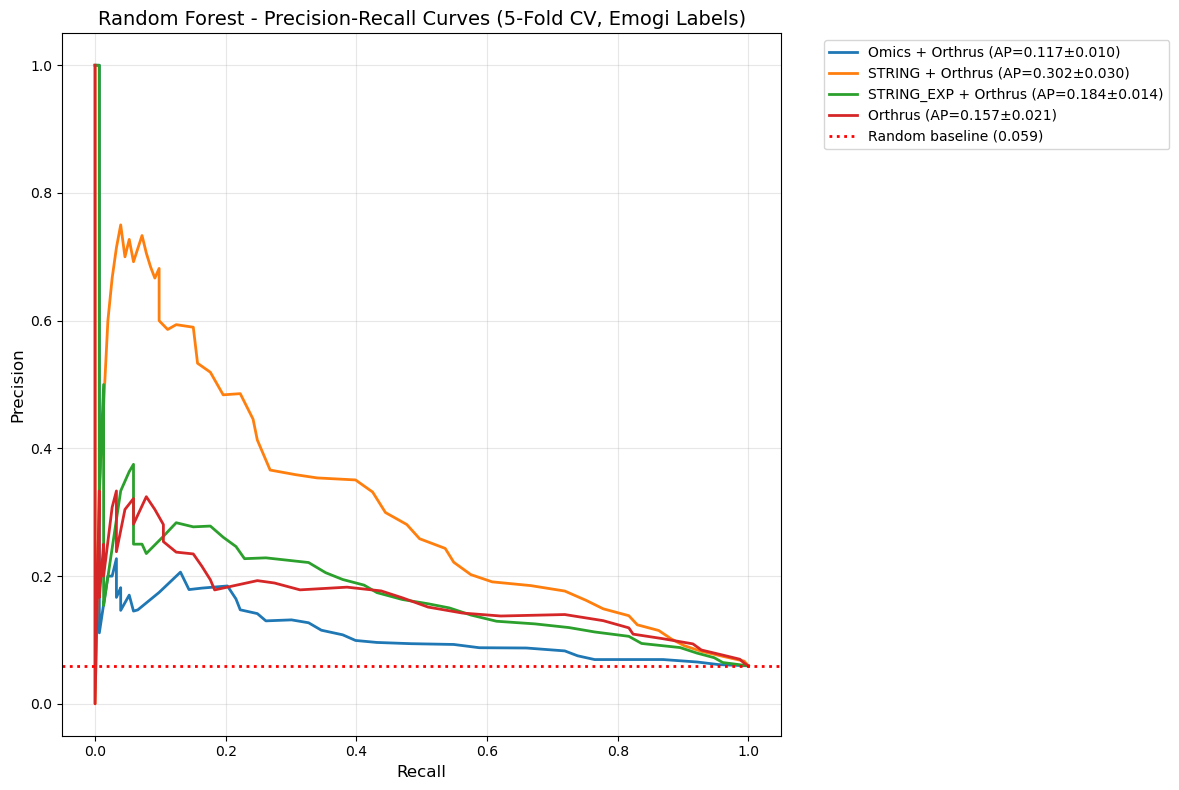

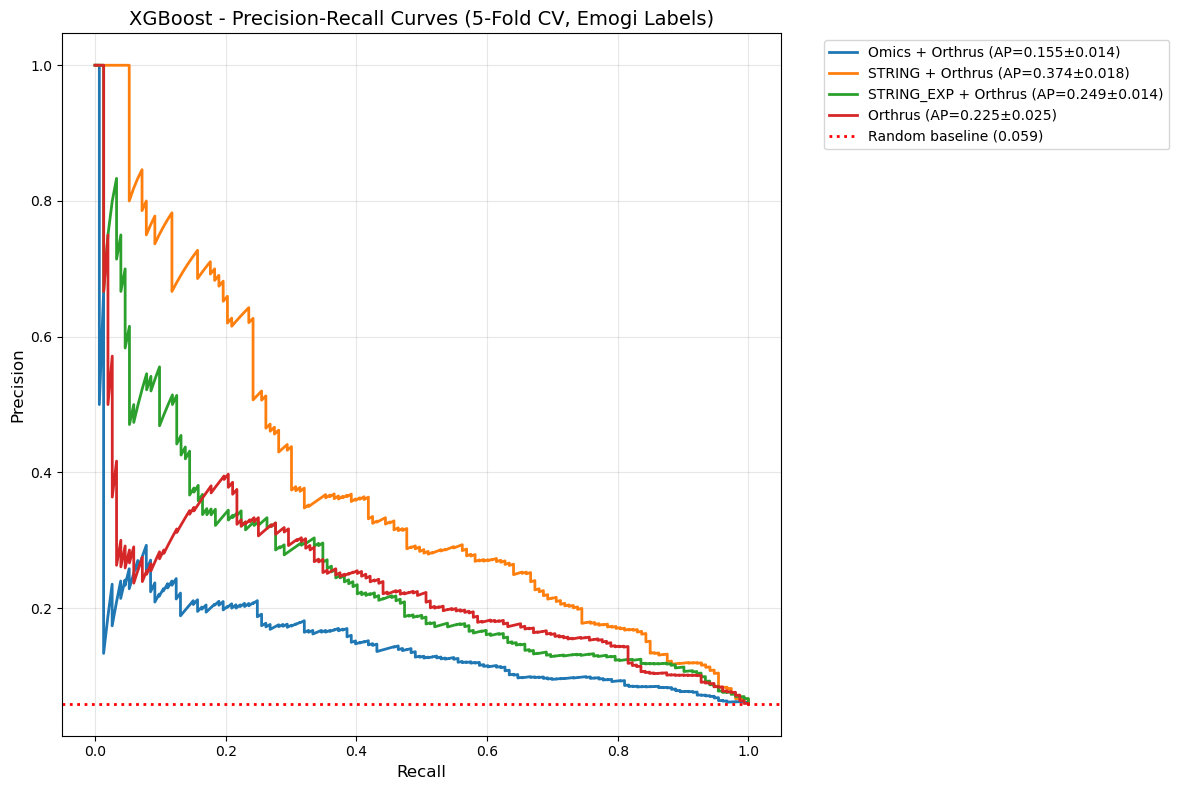

In [31]:
embedding_datasets_ae = {
    'Omics + Orthrus': orthrus_omics_ae,
    'STRING + Orthrus': orthrus_string_ae,
    'STRING_EXP + Orthrus': orthrus_string_exp_ae,
    'Orthrus': orthrus_emogi_ae,
}

results = compare_embeddings_pr_curves(embedding_datasets_ae, emogi, save_plots=False)
print("\nPR Curves Results summary (Mean ± Std):")
print(results.pivot(index='Embedding', columns='Model', values='auPRC'))

Filtered to 12874 common genes across all datasets.
Omics + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)


Omics + Orthrus: RF auPRC=0.117±0.010, XGB auPRC=0.155±0.014
STRING + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
STRING + Orthrus: RF auPRC=0.302±0.030, XGB auPRC=0.374±0.018
STRING_EXP + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
STRING_EXP + Orthrus: RF auPRC=0.184±0.014, XGB auPRC=0.249±0.014
Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
Orthrus: RF auPRC=0.157±0.021, XGB auPRC=0.225±0.025

auPRC Bar Plot Results summary (Mean ± Std):
Model                 Random Forest   XGBoost
Embedding                                    
Omics + Orthrus            0.117481  0.155499
Orthrus                    0.157342  0.225486
STRING + Orthrus           0.302105  0.374015
STRING_EXP + Orthrus       0.184150  0.249071


/data/nasif12/home_if12/kurte/projects/RNA-gene-disease-predictions/Cancer Predictions/common_helper_functions.py:452: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=45, ha='right')
/data/nasif12/home_if12/kurte/projects/RNA-gene-disease-predictions/Cancer Predictions/common_helper_functions.py:452: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=45, ha='right')


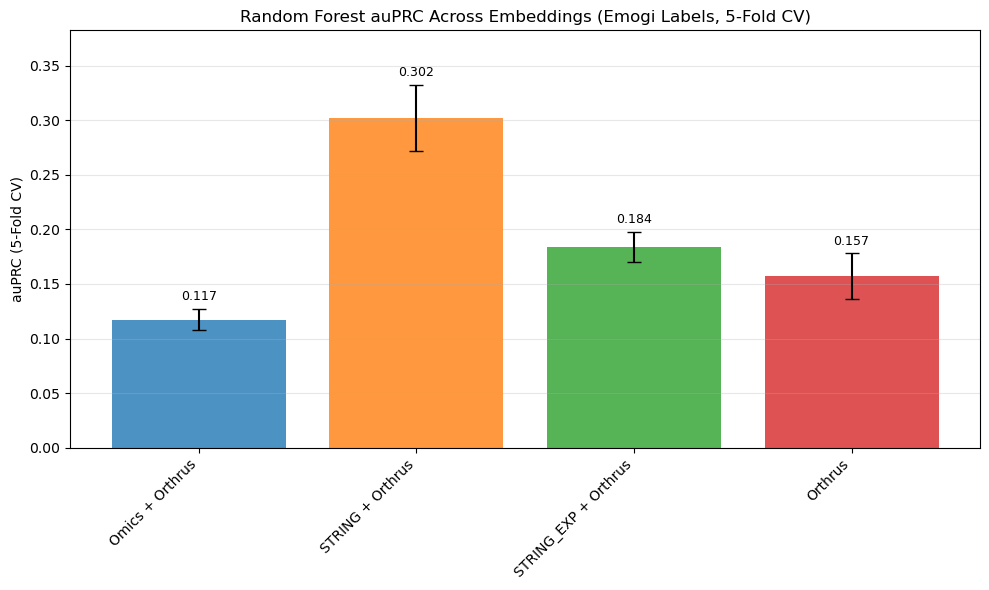

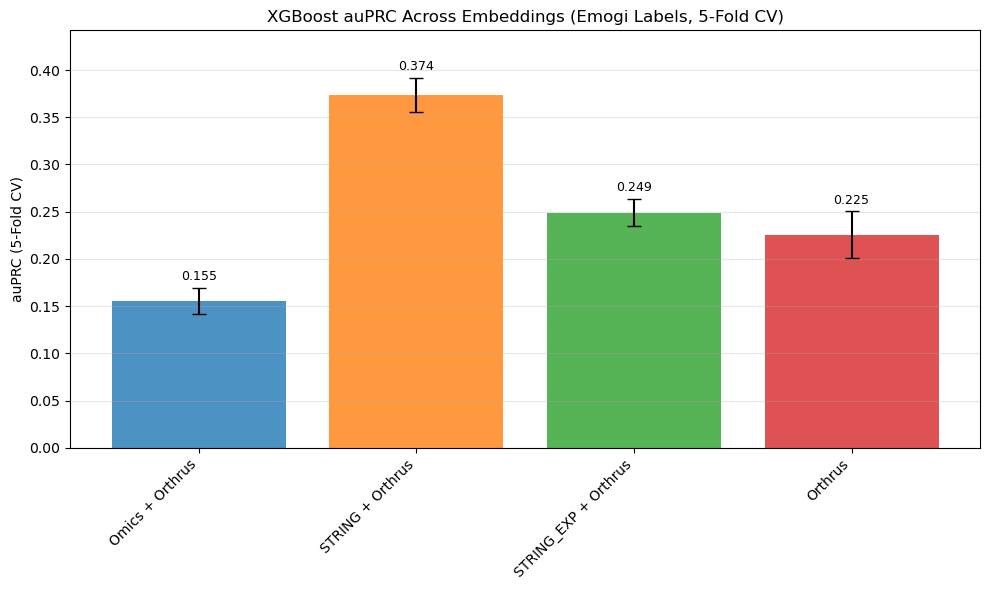

In [ ]:
auprc_results = compare_embeddings_auprc_barplots(embedding_datasets_ae, emogi, save_plots=False)
print("\nauPRC Bar Plot Results summary (Mean ± Std):")
print(auprc_results.pivot(index='Embedding', columns='Model', values='auPRC'))